# Лабораторна робота №5
## Тема: Точність формул для чисельного диференціювання. Метод Рунге-Ромберга. Метод Ейткена.
**Виконав:** Шипка Роман
**Група:** ФЕІ-13

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Визначення функції вологості ґрунту M(t)
def M(t):
    return 50 * np.exp(-0.1 * t) + 5 * np.sin(t)

# Аналітична похідна dM/dt
def dM_dt_exact(t):
    return -5 * np.exp(-0.1 * t) + 5 * np.cos(t)

# Точка дослідження
t0 = 1
exact_val = dM_dt_exact(t0)
print(f"Точне значення похідної в точці t={t0}: {exact_val:.10f}")

Точне значення похідної в точці t=1: -1.8226755608


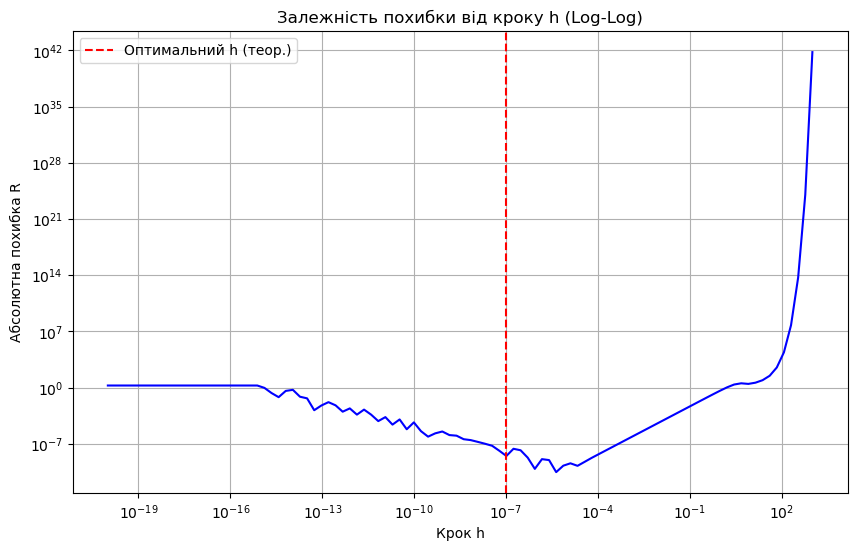

Найкраща точність досягається при h0 ≈ 1e-07


In [3]:
def central_difference(f, t, h):
    return (f(t + h) - f(t - h)) / (2 * h)

# Досліджуємо широкий діапазон кроків: від 10^-20 до 10^3
h_values = np.logspace(-20, 3, 100)
errors = []

for h in h_values:
    approx = central_difference(M, t0, h)
    errors.append(abs(approx - exact_val))

# Візуалізація для пошуку оптимального h
plt.figure(figsize=(10, 6))
plt.loglog(h_values, errors, color='blue')
plt.axvline(x=1e-7, color='red', linestyle='--', label='Оптимальний h (теор.)')
plt.xlabel('Крок h')
plt.ylabel('Абсолютна похибка R')
plt.title('Залежність похибки від кроку h (Log-Log)')
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

# Вибір оптимального h0 (наприклад, 1e-7)
h0 = 1e-7
print(f"Найкраща точність досягається при h0 ≈ {h0}")

In [4]:
h_runge = 0.001
# Обчислення на двох сітках
y_h = central_difference(M, t0, h_runge)
y_2h = central_difference(M, t0, 2 * h_runge)

# Формула Рунге-Ромберга (p=2 для центральної різниці)
y_RR = y_h + (y_h - y_2h) / 3

print(f"Значення за методом Рунге-Ромберга: {y_RR:.10f}")
print(f"Похибка (R2): {abs(y_RR - exact_val):.2e}")

Значення за методом Рунге-Ромберга: -1.8226755608
Похибка (R2): 3.20e-12


In [5]:
h_aitken = 0.001
y_h = central_difference(M, t0, h_aitken)
y_2h = central_difference(M, t0, 2 * h_aitken)
y_4h = central_difference(M, t0, 4 * h_aitken)

# Уточнене значення за Ейткеном
numerator = (y_2h)**2 - y_4h * y_h
denominator = 2 * y_2h - (y_4h + y_h)
y_E = numerator / denominator

# Визначення порядку точності
p = np.log2(abs((y_4h - y_2h) / (y_2h - y_h)))

print(f"Значення за методом Ейткена: {y_E:.10f}")
print(f"Визначений порядок точності p: {p:.2f}")
print(f"Похибка (R3): {abs(y_E - exact_val):.2e}")

Значення за методом Ейткена: -1.8226755609
Визначений порядок точності p: 2.00
Похибка (R3): 2.19e-11


In [6]:
results = {
    "Метод": ["Точне значення", "Центральна різниця (h=0.001)", "Рунге-Ромберг", "Ейткен"],
    "Значення": [exact_val, y_h, y_RR, y_E],
    "Похибка": [0, abs(y_h - exact_val), abs(y_RR - exact_val), abs(y_E - exact_val)]
}

df = pd.DataFrame(results)
print(df.to_string(index=False))

                       Метод  Значення      Похибка
              Точне значення -1.822676 0.000000e+00
Центральна різниця (h=0.001) -1.822676 4.577946e-07
               Рунге-Ромберг -1.822676 3.195888e-12
                      Ейткен -1.822676 2.189071e-11
